# 02. S3 Direct Read, Reproject, and Write
This example demonstrates how to read a file directly from an AWS S3 bucket using the GDAL Virtual File System (`/vsis3/`), reproject it to Web Mercator (EPSG:3857), and load the data to a NumPy array, as well as save it back to S3.

In [ ]:
import curaster
import numpy as np
import matplotlib.pyplot as plt
import os

# This is how S3 Paths can be used
# /vsis3/bucket-name/path/to/raster.tif 
s3_input = "/vsis3/bucket/test_S_2048x2048_lzw_b512_band.tif"
s3_output = "/vsis3/bucket/reprojected_test.tif"

## Define Pipeline
We will reproject the file to `EPSG:3857` and explicitly set the resolution. We also extract a specific band using `.algebra("B1")`.

In [2]:
chain = curaster.open(s3_input) \
    .algebra("B1") \
    .reproject("EPSG:3857", res_x=10.0, res_y=10.0)

print("Output Info:", chain.get_info())

Output Info: {'width': 2813, 'height': 2823, 'geotransform': [1441011.9632014441, 10.0, 0.0, 5173295.247812231, 0.0, -10.0], 'crs': 'PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]'}


## Save to S3

In [3]:
%%time
chain.save_s3(s3_output, verbose=True)
print("S3 write pipeline defined.")

[Reproject] Using 4 threads within 13329 MB VRAM budget.
S3 write pipeline defined.
CPU times: user 314 ms, sys: 1.59 s, total: 1.9 s
Wall time: 2.09 s
0...10...20...30...40...50...60...70...80...90...100 - done.


## Load into NumPy Array
Alternatively, we can load the result directly into system memory.

Numpy Array Shape: (2823, 2813), Dtype: float32


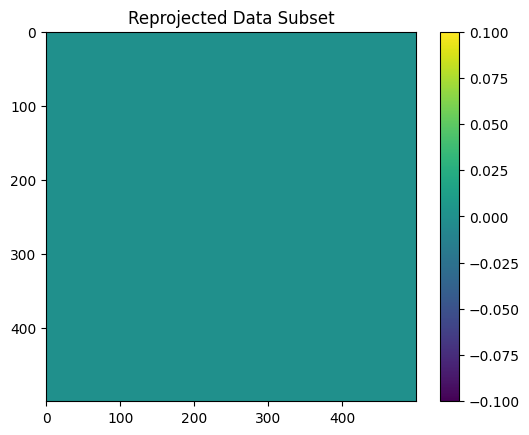

CPU times: user 286 ms, sys: 38.9 ms, total: 325 ms
Wall time: 333 ms


In [4]:
%%time
result = chain.to_memory()

# Extract numpy array
arr = result.data()
print(f"Numpy Array Shape: {arr.shape}, Dtype: {arr.dtype}")

# Quick plot
plt.imshow(arr[100:600, 100:600], cmap="viridis")
plt.title("Reprojected Data Subset")
plt.colorbar()
plt.show()